# Graphs

> Computational Analysis of Social Complexity
>
> Fall 2025, Spencer Lyon

**Prerequisites**

- Python setup
- Python basics
- Python types and methods

**Outcomes**

- Understand key components of networks/graphs
- Use the NetworkX package for working with graphs in Python
- Implement the breadth-first search algorithm

**References**

- [Easley and Kleinberg](https://www.cs.cornell.edu/home/kleinber/networks-book/) chapter 2

## Introduction

### Why Study Graphs?
- Economic, cultural, political, and social interactions are influenced by *structure* of relationships
  - Transmission of viruses
  - International trade, supply chains, marketplaces
  - Spread of information, diffusion of innovation
  - Political persuasion, localized voting patterns
  - Human behaviors influenced by network of friends (sports, clothes, music)
- Behaviors can be effected by social networks
  - "Influencers"
  - Circles of followers can create echo chambers

### Edges and Nodes

- A **graph** specifies relationships between a collection of items
- Each item is called a **node**
- A relationship between nodes is represented by an **edge**
- Visually, graphs might look like this:

![Graphs](https://ucf-cap-6318-resources.s3.amazonaws.com/images/graph_structure.png)

- Here the nodes are `A`, `B`, `C`, `D`
- The edges connect nodes `A-B`, `B-C`, `B-D`, `C-D`

### Adjacency Matrix

- How might we represent the graph above numerically?
- One very common approach is to use a matrix of 0's and 1's called an *adjancency matrix*
- Suppose we have a graph of $N$ nodes
  - Without loss of generality, we'll represent them as integers `0:N-1`
- Let $A \in \{0,1\}^{N \times N}$ be our adjacency matrix
- Element $A_{ij}$ will be zero unless there is an edge between nodes $i$ and $j$ (diagonal is left as $0$)
- In our above we had
  - Nodes `A`, `B`, `C`, `D` (or 0, 1, 2, 3 respectively)
  - Edges connecting nodes `0-1`, `1-2`, `1-3`, `2-3`
- The adjacency matrix for this example is
$$A = \begin{bmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 1 & 1 \\
0 & 1 & 0 & 1 \\
0 & 1 & 1 & 0
\end{bmatrix}$$

## Graphs in Python

- In Python there are a few ways we could represent our example graph above
- We could start with the adjacency matrix concept as follows

In [1]:
import numpy as np

A = np.array([
    [0, 1, 0, 0],
    [1, 0, 1, 1],
    [0, 1, 0, 1],
    [0, 1, 1, 0],
])
A

array([[0, 1, 0, 0],
       [1, 0, 1, 1],
       [0, 1, 0, 1],
       [0, 1, 1, 0]])

### Working with Adjacency Matrices

- An adjacency matrix gives us a lot of information about the structure of the graph
- We could compute all of the following
  - Total number of nodes: number of rows or columns of $A$
  - Total number of edges: $\sum_{ij} A_{ij}$
  - Node with most edges: $\text{argmax}_{i} \sum_{j} A_{i,j}$
  - Average number of edges per node: $\frac{2}{N} \cdot \sum_{i,j>i} A_{i,j}$

### Exercise: Adjacency Matrix

- In the cell below we have defined an adjacency matrix called `A_ex1`
- Using `A_ex1` answer the following questions:
  - How many nodes are in the graph?
  - How many edges?
  - Node with most edges (hint, use the `axis` argument to `A_ex1.sum` and then `np.argmax`)
  - Average number of edges per node
  - Number of connections for the 7th node, i.e. index 6: $\sum_j A_{j,6}$

In [2]:
rng = np.random.default_rng(6318)

A_ex1 = np.zeros((30, 30), dtype=int)

for i in range(30):
    for j in range(i + 1, 30):
        if rng.random() < 0.2:
            A_ex1[i, j] = 1
            A_ex1[j, i] = 1

In [3]:
# Your code here

ex1_total_nodes = None
ex1_total_edges = None
ex1_node_most_edges = None
ex1_average_edges_per_node = None
ex1_connections_node_7 = None

### NetworkX

- There are many smart graph theory experts in the Python community
- They have built a package called NetworkX for working with graphs (along with `matplotlib` for drawing them)
- We can build a `networkx.Graph` object directly from our adjacency matrix

In [4]:
import networkx as nx

In [5]:
G1 = nx.from_numpy_array(A)
G1

In [6]:
list(G1.edges())

[(0, 1), (1, 2), (1, 3), (2, 3)]

In [7]:
list(G1.nodes())  # NetworkX refers to nodes as `nodes`, just like we do

[0, 1, 2, 3]

#### Visualizing Graphs

- We can use NetworkX's drawing functions (built on top of `matplotlib`) to visualize our graph
- Note that the actual placement of the nodes is randomly generated and then tweaked to clearly show all nodes and edges
- The important thing is *not* the placement of nodes, but rather their *relative structure*

In [8]:
import matplotlib.pyplot as plt

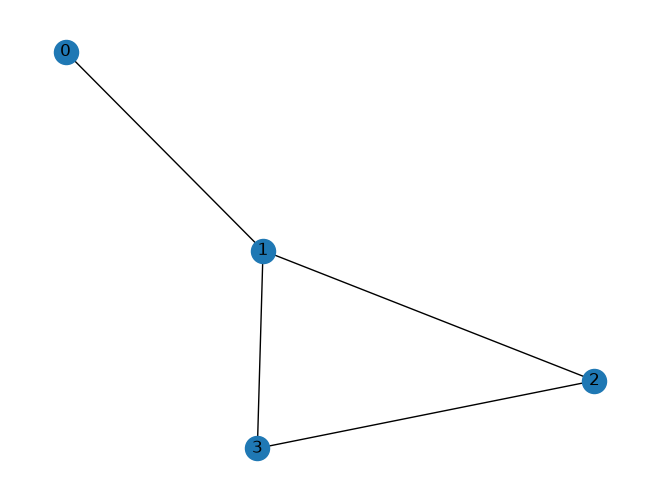

In [9]:
nx.draw(G1, with_labels=True)
plt.show()

### Size considerations

- Using a dense NumPy array to store an adjacency matrix turns out to be a rather costly way to store a graph
- In the original example graph we had 4 nodes and 4 edges
- To store this we needed to have a 4x4 matrix of 64 bit integers
  - This is only (`16 * 64 // 8 == 128`) bytes in our example,
  - But consider a graph of websites and links between them -- that graph would have millions of nodes and edges...
- There are a few approaches to reducing this storage cost:
  - Only store the upper triangle of the matrix
  - Use a NumPy `bool` array instead of an `int` array to store the adjacency matrix (each element only 1 byte!)
  - Use a [`scipy.sparse`](https://docs.scipy.org/doc/scipy/reference/sparse.html) matrix
  - Store as a list of lists (an adjacency list)

In [10]:
# list of lists (adjacency list), 0-indexed
A2 = [[1], [0, 2, 3], [1, 3], [1, 2]]
A2

[[1], [0, 2, 3], [1, 3], [1, 2]]

In [11]:
# NetworkX stores its adjacency information the same way internally
[list(G1.neighbors(n)) for n in G1.nodes()]

[[1], [0, 2, 3], [1, 3], [1, 2]]

## Graph Theory Concepts

- Let's explore some concepts often used in analysis of graphs

### Paths

- When studying graphs it is often natural to ask about how things travel or flow across the graph
- For example, how information spreads amongst a group of friends, how data travels the internet, how diseases are transmitted from one person to another, and how people navigate a metro subway system
- In each of these cases, the flow of things goes from node to node across edges
- A flow from one any node to another node is called a **path**

### Arpanet Example

- Consider the following Graph of the first iteration of the internet

![arpanet](https://ucf-cap-6318-resources.s3.amazonaws.com/images/arpanet_map.png)

- There are many possible paths through this network
- Consider a path from UCSB to MIT: `UCSB-UCLA-RAND-BBN-MIT`
- Another possible path from UCSB to MIT is `UCSB-SRI-UTAH-MIT`

### NetworkX Arpanet

- Let's define the Arpanet using NetworkX as it will be helpful throughout this lecture

In [12]:
nodes = {
    "UCSB": ["SRI", "UCLA"],
    "SRI": ["UCSB", "UCLA", "STAN", "UTAH"],
    "UCLA": ["SRI", "UCSB", "STAN", "RAND"],
    "STAN": ["SRI", "UCLA"],
    "UTAH": ["SRI", "SDC", "MIT"],
    "SDC": ["UTAH", "RAND"],
    "RAND": ["UCLA", "SDC", "BBN"],
    "MIT": ["UTAH", "BBN", "LINC"],
    "BBN": ["MIT", "RAND", "HARV"],
    "LINC": ["MIT", "CASE"],
    "CASE": ["LINC", "CARN"],
    "CARN": ["CASE", "HARV"],
    "HARV": ["CARN", "BBN"],
}

arpa = nx.Graph()
arpa.add_nodes_from(nodes.keys())
for node, neighbors in nodes.items():
    for neighbor in neighbors:
        arpa.add_edge(node, neighbor)


def save_lg(g, path):
    """Save a graph in the LightGraphs.jl `.lg` edge-list format (1-indexed)."""
    node_index = {n: i for i, n in enumerate(g.nodes(), start=1)}
    directed_flag = "d" if g.is_directed() else "u"
    with open(path, "w") as f:
        f.write(f"{g.number_of_nodes()},{g.number_of_edges()},{directed_flag},graph,2,Int64,simplegraph\n")
        for u, v in g.edges():
            f.write(f"{node_index[u]},{node_index[v]}\n")


# save graph for loading in future
save_lg(arpa, "arpanet.lg")

In [13]:
arpa

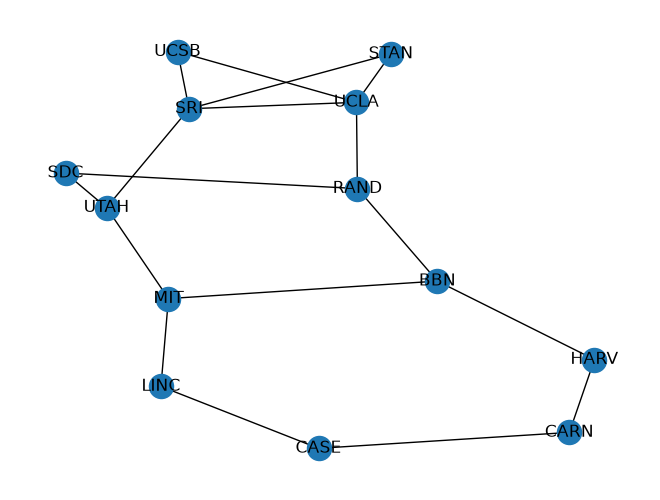

In [14]:
nx.draw(arpa, with_labels=True)
plt.show()

### Degree

- The **degree** of a node is the number of edges connected to it
- In our example graph G1, node B has degree 3 (connected to A, C, and D)
- Node A has degree 1 (only connected to B)
- Degree is a fundamental measure of node importance in a network
  - High-degree nodes are often called "hubs"
  - In social networks, these might be influential people or "connectors"
- We can compute degree directly from the adjacency matrix
  - Degree of node $i$ is $\sum_j A_{ij}$
- NetworkX provides the `degree` method on every graph

In [15]:
dict(G1.degree())

{0: 1, 1: 3, 2: 2, 3: 2}

In [16]:
arpa.degree("MIT")

3

- The degree distribution of a network tells us a lot about its structure
- Many real-world networks have a few high-degree hubs and many low-degree nodes
  - Social networks: celebrities with millions of followers
  - Internet: major websites with many incoming links
  - Transportation: hub airports like Atlanta or Chicago

### Cycles

- An important concept when analyzing graphs is the concept of a cycle
- A cycle is a path that starts and ends at the same node
- For the ARPA net, an example cycle is `LINC-CASE-CARN-HARV-BBN-MIT-LINC`
- Question... what is the shortest possible cycle in a graph (including all endpoints)?
- Cycles appear frequently in real-world networks
  - Friendship networks: if A is friends with B, and B with C, often A and C become friends
  - Transportation networks: cyclical routes allow for redundancy and flexibility
  - Supply chains: cyclical dependencies can create both resilience and vulnerabilities

### Trees

- A **tree** is a connected graph with no cycles
- Trees have exactly N-1 edges for N nodes (the minimum to stay connected)
- Adding any edge to a tree creates a cycle
- Removing any edge from a tree disconnects it
- Trees appear frequently in hierarchical structures
  - Organizational charts: CEO at root, departments as branches
  - Family trees: ancestors and descendants
  - Decision trees: choices branching from initial state
  - File systems: directories and subdirectories
- The breadth-first search we'll see later naturally creates a tree from any graph

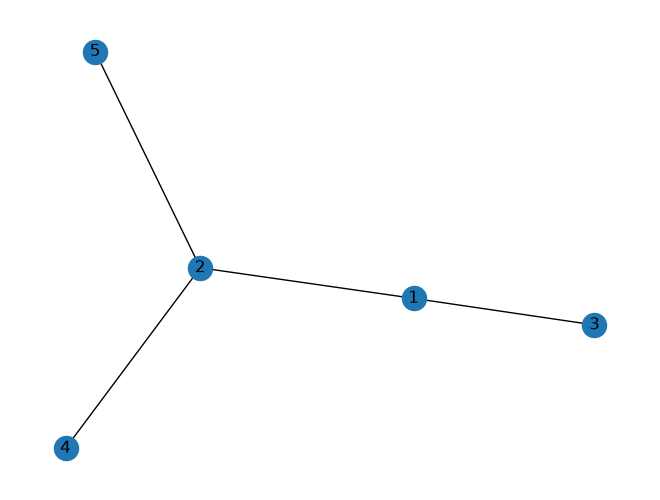

In [17]:
# Example: create a simple tree
tree = nx.Graph()
tree.add_nodes_from(range(1, 6))
tree.add_edges_from([(1, 2), (1, 3), (2, 4), (2, 5)])
nx.draw(tree, with_labels=True)
plt.show()

In [18]:
nx.is_tree(tree)  # NetworkX can check if a graph is a tree

True

In [19]:
nx.is_tree(G1)  # Our original graph has a cycle, so it's not a tree

False

### Connectedness

- A graph is **connected** if there exists a path between every pair of nodes
- In other words, you can travel from any node to any other node by following edges
- The ARPA network was designed to be connected -- ensuring communication between all sites
- We can check if a graph is connected using NetworkX

In [20]:
nx.is_connected(arpa)

True

- It is natural to believe that many real-world networks are connected
  - Transportation: you can get to any station
  - Internet: you can visit any website
- But it is entirely possible to have a non-connected graph
  - Social networks (nodes: people, edges: friendships) of college students who different countries
  - Suppliers for a textile company vs a microchip manufacturer

### Distance

- We can extend concept of paths between nodes, to include a notion of distance
- The **length** of a path is the number of steps it takes from beginning to end
  - `MIT-BBN-RAND-UCLA` has length 3 (starting from `MIT` take three steps before ending at `UCLA`)
- The **distance** between two nodes, is the length of the *shortest* path between those nodes
- NetworkX can compute distances using the `shortest_path_length` function
- Below we compute the distance between `UCLA` and all nodes

In [21]:
nx.shortest_path_length(arpa, source="UCLA")

{'UCLA': 0,
 'UCSB': 1,
 'SRI': 1,
 'STAN': 1,
 'RAND': 1,
 'UTAH': 2,
 'SDC': 2,
 'BBN': 2,
 'MIT': 3,
 'HARV': 3,
 'LINC': 4,
 'CARN': 4,
 'CASE': 5}

## Breadth-First Search

- If asked, how would you go about computing the distance between the `HARV` node and all other nodes?
- One iterative approach might be:
  - Start with `HARV`: note it is distance zero to `HARV`
  - Move on to all nodes directly connected to `HARV`: these are distance 1
  - Then move to all nodes connected to nodes that are distance 1 from `HARV` (excluding any you may have already found): declare these to be at distance 2 from `HARV`
  - Continue traversing edges until you have visited all nodes
- This algorihtm is called **breadth-first search**

### Example: Breadth-First Search from MIT

- The image below shows how breadth-first search would proceed for the MIT node

![mit bfs](https://ucf-cap-6318-resources.s3.amazonaws.com/images/mit_breadth_first.png)

### Exercise (difficult!): BFS

- Now it is time for you to try this out!
- Our goal is to use breadth-first search to compute the distance betwen a given node and all other nodes
- The return value you end up with should be a `list[list]`, where element `i` of this list contains all node labels at distance `i` from the starting node
- Fill in the logic for the `breadth_first_distances` function below
- Your implementation should work for any NetworkX graph (undirected `nx.Graph` or directed `nx.DiGraph`) -- `g.neighbors(n)` returns the right set of neighbors either way

In [22]:
def breadth_first_distances(g, start):
    out = []
    # use out.append(new_nodes) to add to out
    distance = 0

    # TODO: your code here...

    # return out
    return out

In [23]:
# Test code

def test_bfd_methods(val, want):
    if len(val) == 0:
        raise ValueError("Make sure to `append` on to `out` in your function")
    elif len(val) != max(nx.shortest_path_length(arpa, source="HARV").values()):
        raise ValueError("`out` has incorrect number of elements")
    elif [len(v) for v in val] != [len(w) for w in want]:
        raise ValueError("Right number of elements, but not right number in each sublist")
    elif all(sorted(v) == sorted(w) for v, w in zip(val, want)):
        print("correct!")


def run_tests():
    val = breadth_first_distances(arpa, "HARV")
    want = [["BBN", "CARN"], ["RAND", "MIT", "CASE"], ["UCLA", "SDC", "UTAH", "LINC"], ["UCSB", "SRI", "STAN"]]
    test_bfd_methods(val, want)

In [24]:
# uncomment the code below and run when you are ready to test your code
# run_tests()

### BFS with NetworkX

- NetworkX contains routines implementing breadth-first search
- The main function is called `bfs_tree`

In [25]:
bfs_carn = nx.bfs_tree(arpa, "CARN")

- Notice that `bfs_carn` is an `nx.DiGraph` with 13 nodes and 12 edges
- Thus far, all graphs we have considered have been undirected
  - We have only been concerned about if a connection (edge) exists between nodes
- A directed graph extends the notion of connecting nodes with a direction
  - We can now say that *things* flow across edges from one node to another -- always in the same direction
- Why would the breadth-first search routine return a directed graph instead of the undirected type we started with?
- Let's visualize it and see if we can understand why

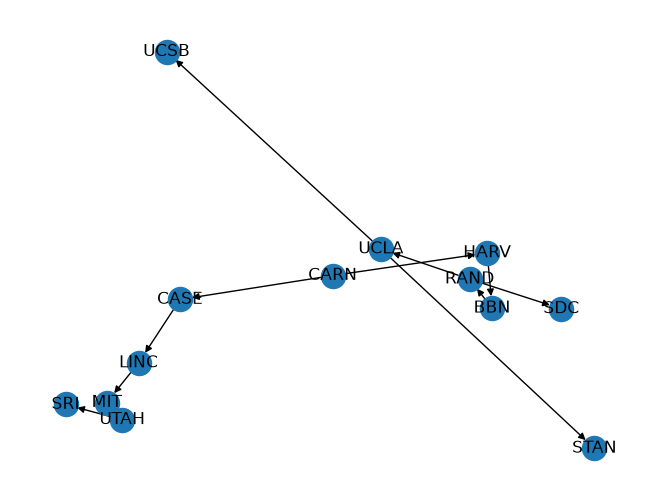

In [26]:
nx.draw(bfs_carn, with_labels=True)
plt.show()

- Notice that arrows only flow *out* of `CARN`
- They also always flow *away* from `CARN`
- The use of directed edges allows NetworkX to represent the shortest path from CARN to any other node
  - For example `STAN`: `CARN -> HARV -> BBN -> RAND -> UCLA -> STAN`

### Exercise: Explore DiGraph

- The `bfs_carn` object is an `nx.DiGraph`
- Let's view its key attributes

In [27]:
[attr for attr in dir(bfs_carn) if not attr.startswith('_')]

['add_edge',
 'add_edges_from',
 'add_node',
 'add_nodes_from',
 'add_weighted_edges_from',
 'adj',
 'adjacency',
 'adjlist_inner_dict_factory',
 'adjlist_outer_dict_factory',
 'clear',
 'clear_edges',
 'copy',
 'degree',
 'edge_attr_dict_factory',
 'edge_subgraph',
 'edges',
 'get_edge_data',
 'graph',
 'graph_attr_dict_factory',
 'has_edge',
 'has_node',
 'has_predecessor',
 'has_successor',
 'in_degree',
 'in_edges',
 'is_directed',
 'is_multigraph',
 'name',
 'nbunch_iter',
 'neighbors',
 'node_attr_dict_factory',
 'node_dict_factory',
 'nodes',
 'number_of_edges',
 'number_of_nodes',
 'order',
 'out_degree',
 'out_edges',
 'pred',
 'predecessors',
 'remove_edge',
 'remove_edges_from',
 'remove_node',
 'remove_nodes_from',
 'reverse',
 'size',
 'subgraph',
 'succ',
 'successors',
 'to_directed',
 'to_directed_class',
 'to_undirected',
 'to_undirected_class',
 'update']

In [28]:
# The `adj` mapping (successors of each node) is the Python analogue of Graphs.jl's `fadjlist`
{n: list(bfs_carn.successors(n)) for n in bfs_carn.nodes()}

{'CARN': ['CASE', 'HARV'],
 'CASE': ['LINC'],
 'HARV': ['BBN'],
 'LINC': ['MIT'],
 'BBN': ['RAND'],
 'MIT': ['UTAH'],
 'RAND': ['UCLA', 'SDC'],
 'UTAH': ['SRI'],
 'UCLA': ['UCSB', 'STAN'],
 'SDC': [],
 'SRI': [],
 'UCSB': [],
 'STAN': []}

- The mapping above has one entry per node
- Each value is a list containing all nodes `j` for which there is an edge flowing from `i` to `j`
- Python does not use multiple dispatch to select a method based on argument types
- Instead, `g.neighbors(n)` already does the right thing for both `nx.Graph` (all neighbors) and `nx.DiGraph` (successors, i.e. out-neighbors)
- That means the `breadth_first_distances` function you wrote above should work *unchanged* on a `DiGraph`
- Let's confirm that below

In [29]:
def test_digraph_ex():
    val = breadth_first_distances(nx.bfs_tree(arpa, "HARV"), "HARV")
    want = [["BBN", "CARN"], ["RAND", "MIT", "CASE"], ["UCLA", "SDC", "UTAH", "LINC"], ["UCSB", "SRI", "STAN"]]
    test_bfd_methods(val, want)

In [30]:
# uncomment the code below when you are ready to test your code!
# test_digraph_ex()

## Components

- A *component* of a graph is a self-contained subset of the nodes
- More precisely, a set of nodes is a component if
  1. Every node in the subset has a path to every other node in the subset
  2. The subset is not part of a larger set with property (1)
- Example:

![components](https://ucf-cap-6318-resources.s3.amazonaws.com/images/graph_components.png)

### Finding Components

- NetworkX provides functions to identify and work with components
- `nx.connected_components(g)` returns an iterator of sets, where each set contains the nodes in one component
- Let's create a graph with multiple components and explore it

In [31]:
# Create a graph with three components
multi_component = nx.Graph()
multi_component.add_nodes_from(range(1, 11))
# Component 1: nodes 1, 2, 3
multi_component.add_edge(1, 2)
multi_component.add_edge(2, 3)
multi_component.add_edge(3, 1)
# Component 2: nodes 4, 5, 6, 7
multi_component.add_edge(4, 5)
multi_component.add_edge(5, 6)
multi_component.add_edge(6, 7)
multi_component.add_edge(7, 4)
# Component 3: nodes 8, 9
multi_component.add_edge(8, 9)
# Node 10 is isolated (its own component)

In [32]:
components = [sorted(c) for c in nx.connected_components(multi_component)]

In [33]:
print("Number of components:", len(components))
for i, comp in enumerate(components, start=1):
    print(f"Component {i} has {len(comp)} nodes: {comp}")

Number of components: 4
Component 1 has 3 nodes: [1, 2, 3]
Component 2 has 4 nodes: [4, 5, 6, 7]
Component 3 has 2 nodes: [8, 9]
Component 4 has 1 nodes: [10]


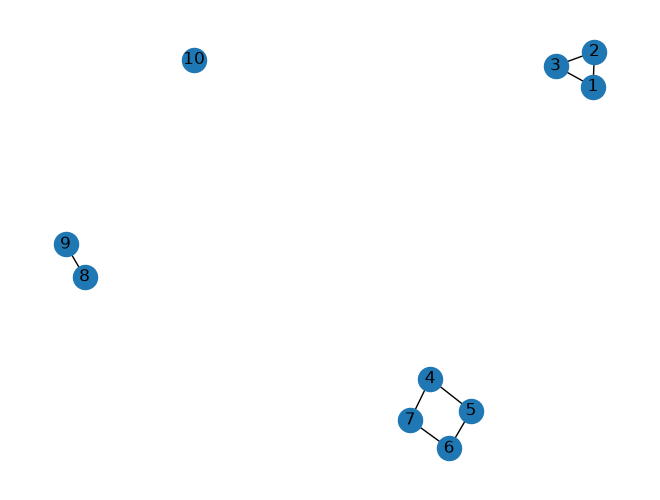

In [34]:
nx.draw(multi_component, with_labels=True)
plt.show()

### Why Components Matter

- Components help us understand the structure of social networks
- Each component represents a group that can communicate internally but not with other groups
- In social network analysis, components reveal:
  - **Information silos**: Ideas spread within components but not between them
  - **Echo chambers**: Opinions reinforce within isolated groups
  - **Community detection**: Natural groupings in social structures
  - **Influence boundaries**: Limits of where influence can spread

### Real-World Implications

- **Disease spread**: Each component represents a boundary for transmission
  - COVID-19 travel restrictions aimed to keep countries as separate components
  - Contact tracing identifies components to contain outbreaks
- **Marketing**: Products spread through word-of-mouth within components
  - Need to seed each component separately for full market penetration
  - Viral marketing campaigns can fail if they don't bridge components
- **Political polarization**: Separate components in social media
  - Different groups may never see opposing viewpoints
  - Bridging nodes between components become crucial for dialogue
- **Infrastructure resilience**: Power grids, internet backbone
  - Multiple components mean system fragmentation after failures
  - Redundant connections prevent network from splitting into components

### Giant Component

- Many real-world networks have a **giant component** containing most nodes
- Plus several small components or isolated nodes
- Let's check if ARPANET has this structure

In [35]:
arpa_components = list(nx.connected_components(arpa))
print(f"ARPANET has {len(arpa_components)} component(s)")
print("Component sizes:", [len(c) for c in arpa_components])

ARPANET has 1 component(s)
Component sizes: [13]


- ARPANET is fully connected (one component) by design
- This ensures any site can communicate with any other site
- Network resilience was a key design goal for the early internet

## Example

- How many components are in this graph?

![hs dating](https://ucf-cap-6318-resources.s3.amazonaws.com/images/hs_dating_graph.png)

## Real-World Network Examples

- Let's analyze some actual network datasets to see these concepts in practice
- We'll look at:
  - Zachary's Karate Club: A classic social network dataset
  - Facebook ego networks: Social connections from real Facebook data
  - Email networks: Communication patterns in organizations

### Zachary's Karate Club

- Famous dataset from sociology (Zachary, 1977)
- Documents friendships in a karate club that split into two factions
- 34 members (nodes), 78 friendships (edges)
- Perfect for studying community structure and components

In [36]:
# NetworkX includes several famous networks as built-in datasets!
karate = nx.karate_club_graph()

In [37]:
# Analyze the karate club network
print("Karate Club Network:")
print("  Nodes:", karate.number_of_nodes())
print("  Edges:", karate.number_of_edges())
print("  Average degree:", round(np.mean([d for _, d in karate.degree()]), 2))
print("  Is connected:", nx.is_connected(karate))

Karate Club Network:
  Nodes: 34
  Edges: 78
  Average degree: 4.59
  Is connected: True


In [38]:
# Look at degree distribution
degrees = dict(karate.degree())
print("\nDegree distribution:")
print("  Min degree:", min(degrees.values()))
print("  Max degree:", max(degrees.values()))
print("  Node with most connections:", max(degrees, key=degrees.get))


Degree distribution:
  Min degree: 1
  Max degree: 17
  Node with most connections: 33


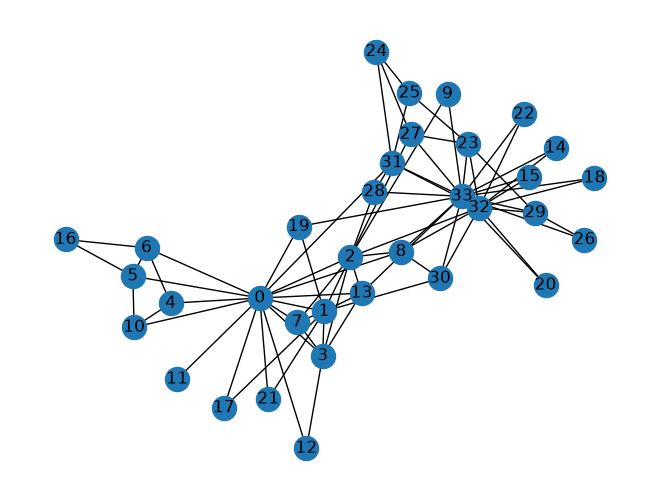

In [39]:
# Visualize the karate club network
nx.draw(karate, with_labels=True, node_size=300)
plt.show()

### Exercise: Analyzing the Petersen Graph

- The Petersen graph is a famous graph in graph theory
- It appears in many theoretical results and counterexamples
- Your task: analyze this network's structure

In [40]:
# Load the Petersen graph
petersen = nx.petersen_graph()

# TODO: Calculate the following properties
num_nodes = None              # Total number of nodes
num_edges = None              # Total number of edges
avg_degree = None             # Average degree (should be the same for all nodes!)
is_it_connected = None        # Is the graph connected?
is_it_tree = None             # Is it a tree?
num_components = None         # How many components?

# Print your results
print("Petersen Graph Analysis:")
print("  Number of nodes:", num_nodes)
print("  Number of edges:", num_edges)
print("  Average degree:", avg_degree)
print("  Is connected:", is_it_connected)
print("  Is it a tree:", is_it_tree)
print("  Number of components:", num_components)

Petersen Graph Analysis:
  Number of nodes: None
  Number of edges: None
  Average degree: None
  Is connected: None
  Is it a tree: None
  Number of components: None


### Other Built-in Networks

- NetworkX includes many classic networks for teaching and research
- Some interesting examples you can explore:

In [41]:
# Examples of other built-in graphs
graphs_to_explore = [
    nx.house_graph,        # The "house" graph (5 nodes)
    nx.bull_graph,         # The bull graph
    nx.cubical_graph,      # 3-dimensional cube
    nx.diamond_graph,      # Diamond graph
    nx.dodecahedral_graph, # Dodecahedron graph (20 nodes)
    nx.heawood_graph,      # Heawood graph (14 nodes)
    nx.moebius_kantor_graph,  # Möbius-Kantor graph
    nx.octahedral_graph,   # Octahedron graph
    nx.pappus_graph,       # Pappus graph
    nx.tutte_graph,        # Tutte graph (46 nodes)
]

# Try loading and analyzing one!
# Example: g = nx.house_graph()